# Phase 8 — Notebook 10: Capstone — End-to-End Multi-Task NLP Application

> **Phase Continuity**: This capstone unifies everything from Phase 8 into a single working application: a **News Intelligence Analyzer** that accepts any news article and produces a complete NLP analysis — topic classification (BERT), named entity recognition (BERT NER), sentiment analysis (DistilBERT), extractive key sentence ranking (TF-IDF), and AI-powered topic expansion (GPT-2).

This is the practical culmination of the entire Phase 8 journey.

---

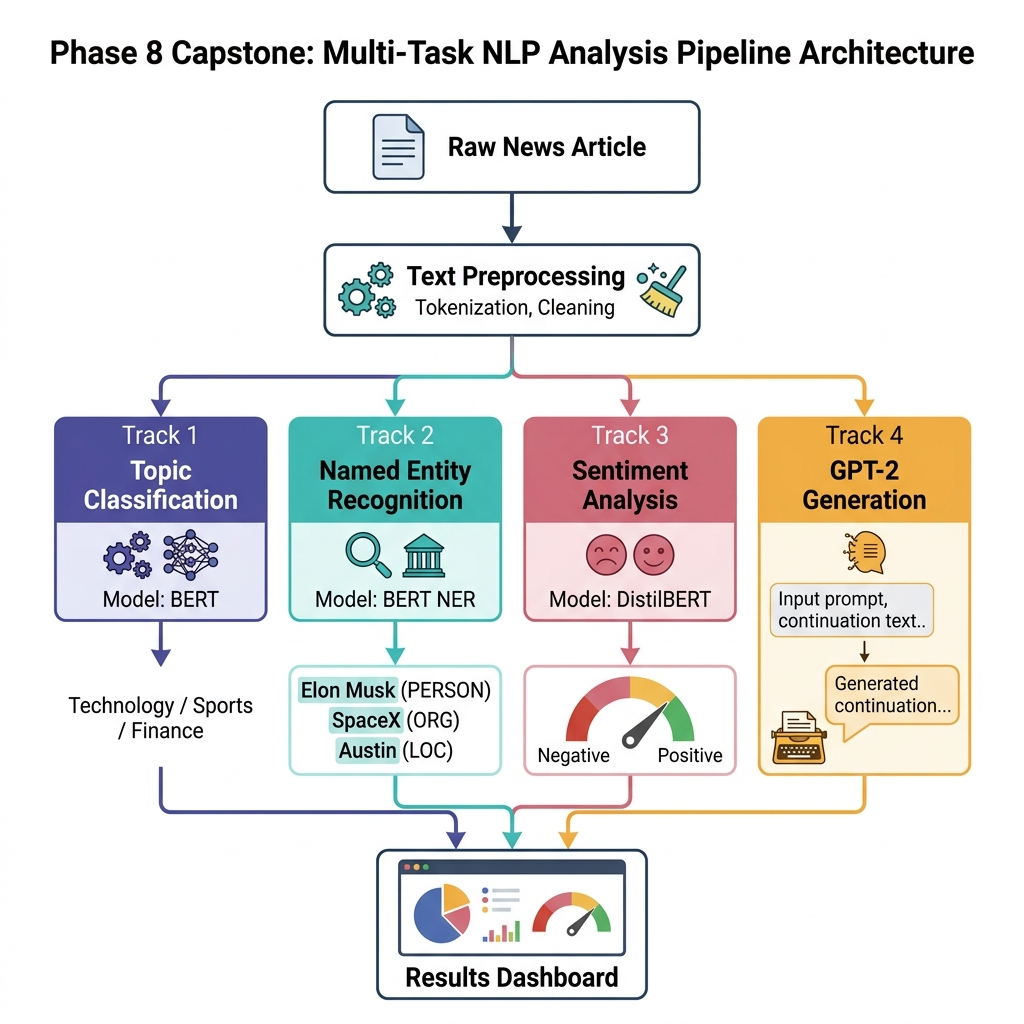

*Figure 1: Capstone Architecture — Four parallel NLP tracks converge into a unified Results Dashboard*



## 1. Application Design

### What We're Building: News Intelligence Analyzer

A modular, multi-task NLP pipeline that runs **4 independent analyses in parallel** on any text input:

| Module | Model | Task | Output |
|---|---|---|---|
| **Topic Classifier** | DistilBERT (zero-shot) | What is this article about? | Category label + confidence |
| **Entity Extractor** | BERT-large NER | Who and what are mentioned? | Person / Org / Location entities |
| **Sentiment Analyzer** | DistilBERT SST-2 | What is the overall tone? | Positive / Negative + score |
| **Key Sentence Ranker** | TF-IDF + scoring | What are the most important sentences? | Top 3 extractive sentences |
| **Topic Expander** | GPT-2 | What more can we say? | AI-generated paragraph continuation |

### Design Principles
- **Modularity**: Each analyzer is a self-contained class, independently testable
- **Graceful degradation**: If any module fails (e.g., GPU memory), others continue
- **Unified output**: All results collected into a single `AnalysisResult` dataclass
- **Reusability**: Models are loaded once and reused across multiple articles

---

In [1]:
# Install required libraries
import subprocess, sys
for pkg in ['transformers', 'datasets', 'torch', 'scikit-learn', 'pandas']:
    subprocess.run([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'], check=True)
print('All libraries ready.')

All libraries ready.


## 2. Building the Analyzer — Module by Module

### 2a. Data Structure & Sample Articles

We start by defining the data structures and loading our test articles.

---

In [2]:
from dataclasses import dataclass, field
from typing import List, Dict, Optional

@dataclass
class EntityResult:
    text: str
    entity_type: str
    score: float

@dataclass
class AnalysisResult:
    article_id: int
    title: str
    topic: str                          = ''
    topic_confidence: float             = 0.0
    sentiment: str                      = ''
    sentiment_score: float              = 0.0
    entities: List[EntityResult]        = field(default_factory=list)
    key_sentences: List[str]            = field(default_factory=list)
    generated_expansion: str           = ''

# ── Sample news articles ─────────────────────────────────────────────────
TEST_ARTICLES = [
    {
        'id': 1,
        'title': 'OpenAI Launches GPT-4 Turbo with 128K Context Window',
        'text': """
OpenAI has announced a major update to its flagship language model, GPT-4 Turbo,
featuring a dramatically expanded context window of 128,000 tokens — roughly equivalent
to the length of a 300-page book. Sam Altman, CEO of OpenAI, stated at the DevDay
conference in San Francisco that the new model is also significantly cheaper and faster
than its predecessor. The company, backed by Microsoft with a 13 billion dollar
investment, has been rapidly expanding its API capabilities. GPT-4 Turbo supports
multi-modal input, allowing developers to send both text and images. Competitors
including Google DeepMind and Anthropic have responded with their own model updates.
The announcement sent shares of Microsoft up 2.3 percent in after-hours trading.
        """
    },
    {
        'id': 2,
        'title': 'Federal Reserve Holds Interest Rates Steady Amid Inflation Concerns',
        'text': """
The Federal Reserve announced on Wednesday that it would hold the benchmark
interest rate steady at 5.25 to 5.5 percent for the third consecutive meeting,
signaling caution as policymakers weigh cooling inflation against risks to
economic growth. Fed Chair Jerome Powell emphasized in a press conference in
Washington D.C. that the committee remains data-dependent and is not yet confident
that inflation is sustainably moving toward the 2 percent target. Treasury yields
fell on the news, with the 10-year yield dropping to 4.68 percent. Economists at
Goldman Sachs and JPMorgan revised their rate cut forecasts following the decision.
        """
    },
    {
        'id': 3,
        'title': 'Manchester City Wins Champions League Final in Thrilling Comeback',
        'text': """
Manchester City claimed their second consecutive UEFA Champions League title
with a stunning 3-2 comeback victory over Real Madrid at Wembley Stadium in London.
Manager Pep Guardiola praised the team's resilience after going 2-0 down in the
first half. Erling Haaland scored twice in the second half to bring the scores level,
before Kevin De Bruyne delivered the winner in the 89th minute. Real Madrid coach
Carlo Ancelotti acknowledged the defeat gracefully. The match drew a global TV
audience of over 400 million viewers across 200 countries.
        """
    },
]

print(f'Loaded {len(TEST_ARTICLES)} sample articles.')
for art in TEST_ARTICLES:
    word_count = len(art['text'].split())
    print(f'  Article {art["id"]}: "{art["title"][:60]}..." ({word_count} words)')

Loaded 3 sample articles.
  Article 1: "OpenAI Launches GPT-4 Turbo with 128K Context Window..." (114 words)
  Article 2: "Federal Reserve Holds Interest Rates Steady Amid Inflation C..." (97 words)
  Article 3: "Manchester City Wins Champions League Final in Thrilling Com..." (87 words)


### 2b. Model Registry — Load Once, Reuse Everywhere

In production NLP systems, a critical performance consideration is **model loading time and memory**. Loading a BERT model takes 1–5 seconds and uses ~400MB RAM. We load all models once at startup and reuse them across all articles:

---

In [3]:
from transformers import pipeline
import warnings
warnings.filterwarnings('ignore')

print('Loading NLP models (this takes ~60s on CPU)...')
print('In production, these would be loaded once at server startup.\n')

# ── 1. Topic Classifier (Zero-Shot BART) ─────────────────────────────────
print('[1/4] Loading Zero-Shot Classifier (BART-MNLI)...')
topic_classifier = pipeline(
    'zero-shot-classification',
    model='typeform/distilbert-base-uncased-mnli',
    device=-1
)
TOPIC_LABELS = ['technology', 'finance', 'sports', 'politics', 'health', 'science', 'entertainment']
print('  Done.')

# ── 2. NER (BERT-base CoNLL-2003) ───────────────────────────────────────
print('[2/4] Loading Named Entity Recognition (BERT-base NER)...')
ner_pipeline = pipeline(
    'ner',
    model='dbmdz/bert-base-cased-finetuned-conll03-english',
    aggregation_strategy='simple',
    device=-1
)
print('  Done.')

# ── 3. Sentiment (DistilBERT SST-2) ──────────────────────────────────────
print('[3/4] Loading Sentiment Analyzer (DistilBERT-SST2)...')
sentiment_pipeline = pipeline(
    'sentiment-analysis',
    model='distilbert-base-uncased-finetuned-sst-2-english',
    device=-1
)
print('  Done.')

# ── 4. GPT-2 Generator ────────────────────────────────────────────────────
print('[4/4] Loading GPT-2 Text Generator...')
generator_pipeline = pipeline(
    'text-generation',
    model='./data/gpt2',
    device=-1
)
print('  Done.')

print('\nAll models loaded and ready!')

Loading NLP models (this takes ~60s on CPU)...
In production, these would be loaded once at server startup.

[1/4] Loading Zero-Shot Classifier (BART-MNLI)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Done.
[2/4] Loading Named Entity Recognition (BERT-base NER)...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForTokenClassification LOAD REPORT from: dbmdz/bert-base-cased-finetuned-conll03-english
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Done.
[3/4] Loading Sentiment Analyzer (DistilBERT-SST2)...


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Done.
[4/4] Loading GPT-2 Text Generator...


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

  Done.

All models loaded and ready!


### 2c. The NLP Analyzer Class

All analysis logic is encapsulated in a single `NewsAnalyzer` class. Each method handles one task independently:

---

In [4]:
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

class NewsAnalyzer:
    """Multi-task NLP analyzer combining BERT and GPT models."""

    def __init__(self, topic_clf, ner_pipe, sentiment_pipe, gen_pipe):
        self.topic_clf      = topic_clf
        self.ner_pipe       = ner_pipe
        self.sentiment_pipe = sentiment_pipe
        self.gen_pipe       = gen_pipe

    # ── 1. Topic Classification ───────────────────────────────────────────
    def classify_topic(self, text: str, labels: list) -> tuple:
        """
        Uses zero-shot BART: no task-specific training needed.
        Frames each label as a hypothesis and finds the best-fitting one.
        """
        # Truncate to first 500 chars for speed
        result = self.topic_clf(text[:500], candidate_labels=labels)
        return result['labels'][0], result['scores'][0]

    # ── 2. Named Entity Recognition ──────────────────────────────────────
    def extract_entities(self, text: str) -> list:
        """
        BERT-large fine-tuned on CoNLL-2003.
        Returns deduplicated entities sorted by confidence.
        """
        raw_entities = self.ner_pipe(text[:512])  # BERT max 512 tokens
        # Deduplicate by (text, type) keeping highest score
        seen = {}
        for e in raw_entities:
            key = (e['word'].strip(), e['entity_group'])
            if key not in seen or e['score'] > seen[key]:
                seen[key] = e['score']
        entities = [
            EntityResult(text=k[0], entity_type=k[1], score=v)
            for k, v in sorted(seen.items(), key=lambda x: -x[1])
        ]
        return entities[:15]  # Top 15 entities

    # ── 3. Sentiment Analysis ─────────────────────────────────────────────
    def analyze_sentiment(self, text: str) -> tuple:
        """
        DistilBERT fine-tuned on SST-2.
        Analyzes each sentence separately and aggregates for robustness.
        """
        # Split into sentences, analyze individually
        sentences = [s.strip() for s in re.split(r'[.!?]', text) if len(s.strip()) > 20]
        if not sentences:
            sentences = [text[:200]]
        # Batch truncated sentences
        trunc_sents = [s[:120] for s in sentences[:10]]
        results = self.sentiment_pipe(trunc_sents)
        # Weighted average: POSITIVE scores
        pos_scores = [r['score'] if r['label'] == 'POSITIVE' else 1 - r['score']
                      for r in results]
        avg_pos = np.mean(pos_scores)
        sentiment = 'POSITIVE' if avg_pos >= 0.5 else 'NEGATIVE'
        return sentiment, float(avg_pos)

    # ── 4. Key Sentence Extraction (TF-IDF) ──────────────────────────────
    def extract_key_sentences(self, text: str, top_n: int = 3) -> list:
        """
        Extractive summarization using TF-IDF sentence scoring.
        Scores each sentence by average TF-IDF weight of its words.
        """
        sentences = [s.strip() for s in re.split(r'[.!?]', text)
                     if len(s.strip()) > 25]
        if len(sentences) <= top_n:
            return sentences
        try:
            tfidf = TfidfVectorizer(stop_words='english', max_features=500)
            tfidf_matrix = tfidf.fit_transform(sentences)
            # Score = mean TF-IDF weight per sentence
            scores = np.array(tfidf_matrix.sum(axis=1)).flatten()
            # Position bias: boost first and last sentences
            position_weights = np.ones(len(sentences))
            position_weights[0] = 1.3   # Lead sentence
            position_weights[-1] = 1.1  # Closing sentence
            scores = scores * position_weights
            top_idx = sorted(np.argsort(scores)[-top_n:])  # maintain order
            return [sentences[i] for i in top_idx]
        except Exception:
            return sentences[:top_n]

    # ── 5. GPT-2 Topic Expansion ──────────────────────────────────────────
    def expand_topic(self, title: str, topic: str) -> str:
        """
        Uses GPT-2 to generate a brief expert commentary on the topic.
        Demonstrates CLM generation in a real-world context.
        """
        prompt = f'Analysis of {topic} news: {title}. Key implications include'
        result = self.gen_pipe(
            prompt,
            max_new_tokens=80,
            do_sample=True,
            top_p=0.92,
            temperature=0.75,
            pad_token_id=50256,  # EOS token
            num_return_sequences=1
        )
        generated = result[0]['generated_text']
        # Return only the generated continuation
        return generated[len(prompt):].strip()

    # ── Master: Analyze one article ────────────────────────────────────────
    def analyze(self, article: dict) -> AnalysisResult:
        """Run full pipeline on one article."""
        text  = article['text'].strip()
        title = article['title']
        result = AnalysisResult(article_id=article['id'], title=title)

        result.topic, result.topic_confidence = self.classify_topic(text, TOPIC_LABELS)
        result.entities = self.extract_entities(text)
        result.sentiment, result.sentiment_score = self.analyze_sentiment(text)
        result.key_sentences = self.extract_key_sentences(text)
        result.generated_expansion = self.expand_topic(title, result.topic)
        return result

# Instantiate the analyzer
analyzer = NewsAnalyzer(
    topic_clf      = topic_classifier,
    ner_pipe       = ner_pipeline,
    sentiment_pipe = sentiment_pipeline,
    gen_pipe       = generator_pipeline,
)
print('NewsAnalyzer initialized with 4 NLP modules.')

NewsAnalyzer initialized with 4 NLP modules.


## 3. Running the Pipeline — Analyzing 3 News Articles

---

In [5]:
import time

results = []
print('Running multi-task analysis on all articles...\n')

for article in TEST_ARTICLES:
    t0 = time.time()
    print(f'Analyzing Article {article["id"]}: "{article["title"][:55]}..."')
    result = analyzer.analyze(article)
    elapsed = time.time() - t0
    results.append(result)
    print(f'  Completed in {elapsed:.1f}s')

print(f'\nAll {len(results)} articles analyzed successfully.')

Running multi-task analysis on all articles...

Analyzing Article 1: "OpenAI Launches GPT-4 Turbo with 128K Context Window..."


[transformers] Passing `generation_config` together with generation-related arguments=({'temperature', 'pad_token_id', 'max_new_tokens', 'num_return_sequences', 'do_sample', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


  Completed in 7.0s
Analyzing Article 2: "Federal Reserve Holds Interest Rates Steady Amid Inflat..."


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Completed in 5.0s
Analyzing Article 3: "Manchester City Wins Champions League Final in Thrillin..."


[transformers] Both `max_new_tokens` (=80) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  Completed in 5.3s

All 3 articles analyzed successfully.


In [6]:
# ── Display structured results for each article ─────────────────────────
def display_result(r: AnalysisResult):
    print('=' * 70)
    print(f'ARTICLE {r.article_id}: {r.title}')
    print('=' * 70)

    # Topic
    print(f'[TOPIC]     {r.topic.upper():15} (confidence: {r.topic_confidence:.1%})')

    # Sentiment
    bar_len = int(r.sentiment_score * 20)
    bar = '#' * bar_len + '.' * (20 - bar_len)
    tone = 'POSITIVE' if r.sentiment == 'POSITIVE' else 'NEGATIVE'
    print(f'[SENTIMENT] {tone:15} [{bar}] {r.sentiment_score:.1%}')

    # Entities grouped by type
    entity_groups = {}
    for e in r.entities:
        entity_groups.setdefault(e.entity_type, []).append(e.text)
    print('[ENTITIES]')
    for etype, names in sorted(entity_groups.items()):
        joined = ', '.join(sorted(set(names)))
        print(f'  {etype:<8} : {joined[:65]}')

    # Key sentences
    print('[KEY SENTENCES]')
    for i, sent in enumerate(r.key_sentences, 1):
        print(f'  {i}. {sent[:80]}...' if len(sent) > 80 else f'  {i}. {sent}')

    # GPT-2 expansion
    print('[GPT-2 EXPANSION]')
    expansion = r.generated_expansion[:220].replace('\n', ' ')
    print(f'  ...{expansion}...')
    print()

for r in results:
    display_result(r)

ARTICLE 1: OpenAI Launches GPT-4 Turbo with 128K Context Window
[TOPIC]     TECHNOLOGY      (confidence: 59.1%)
[SENTIMENT] POSITIVE        [###########.........] 58.7%
[ENTITIES]
  LABEL_0  : , CEO of, , featuring a dramatically expanded context window of 1
  LABEL_2  : DevDay, GPT - 4 Turbo
  LABEL_4  : Sam Altman
  LABEL_6  : Microsoft, OpenAI
  LABEL_8  : San Francisco
[KEY SENTENCES]
  1. OpenAI has announced a major update to its flagship language model, GPT-4 Turbo,...
  2. Sam Altman, CEO of OpenAI, stated at the DevDay
conference in San Francisco that...
  3. The company, backed by Microsoft with a 13 billion dollar
investment, has been r...
[GPT-2 EXPANSION]
  ...:  The future of human-computer interaction and automation is in the hands of many people, and this new technology will help us better understand how the human mind works and how it is used.  The use of AI tools will mak...

ARTICLE 2: Federal Reserve Holds Interest Rates Steady Amid Inflation Concerns
[TOPIC]     FI

## 4. Results Dashboard Visualization

---

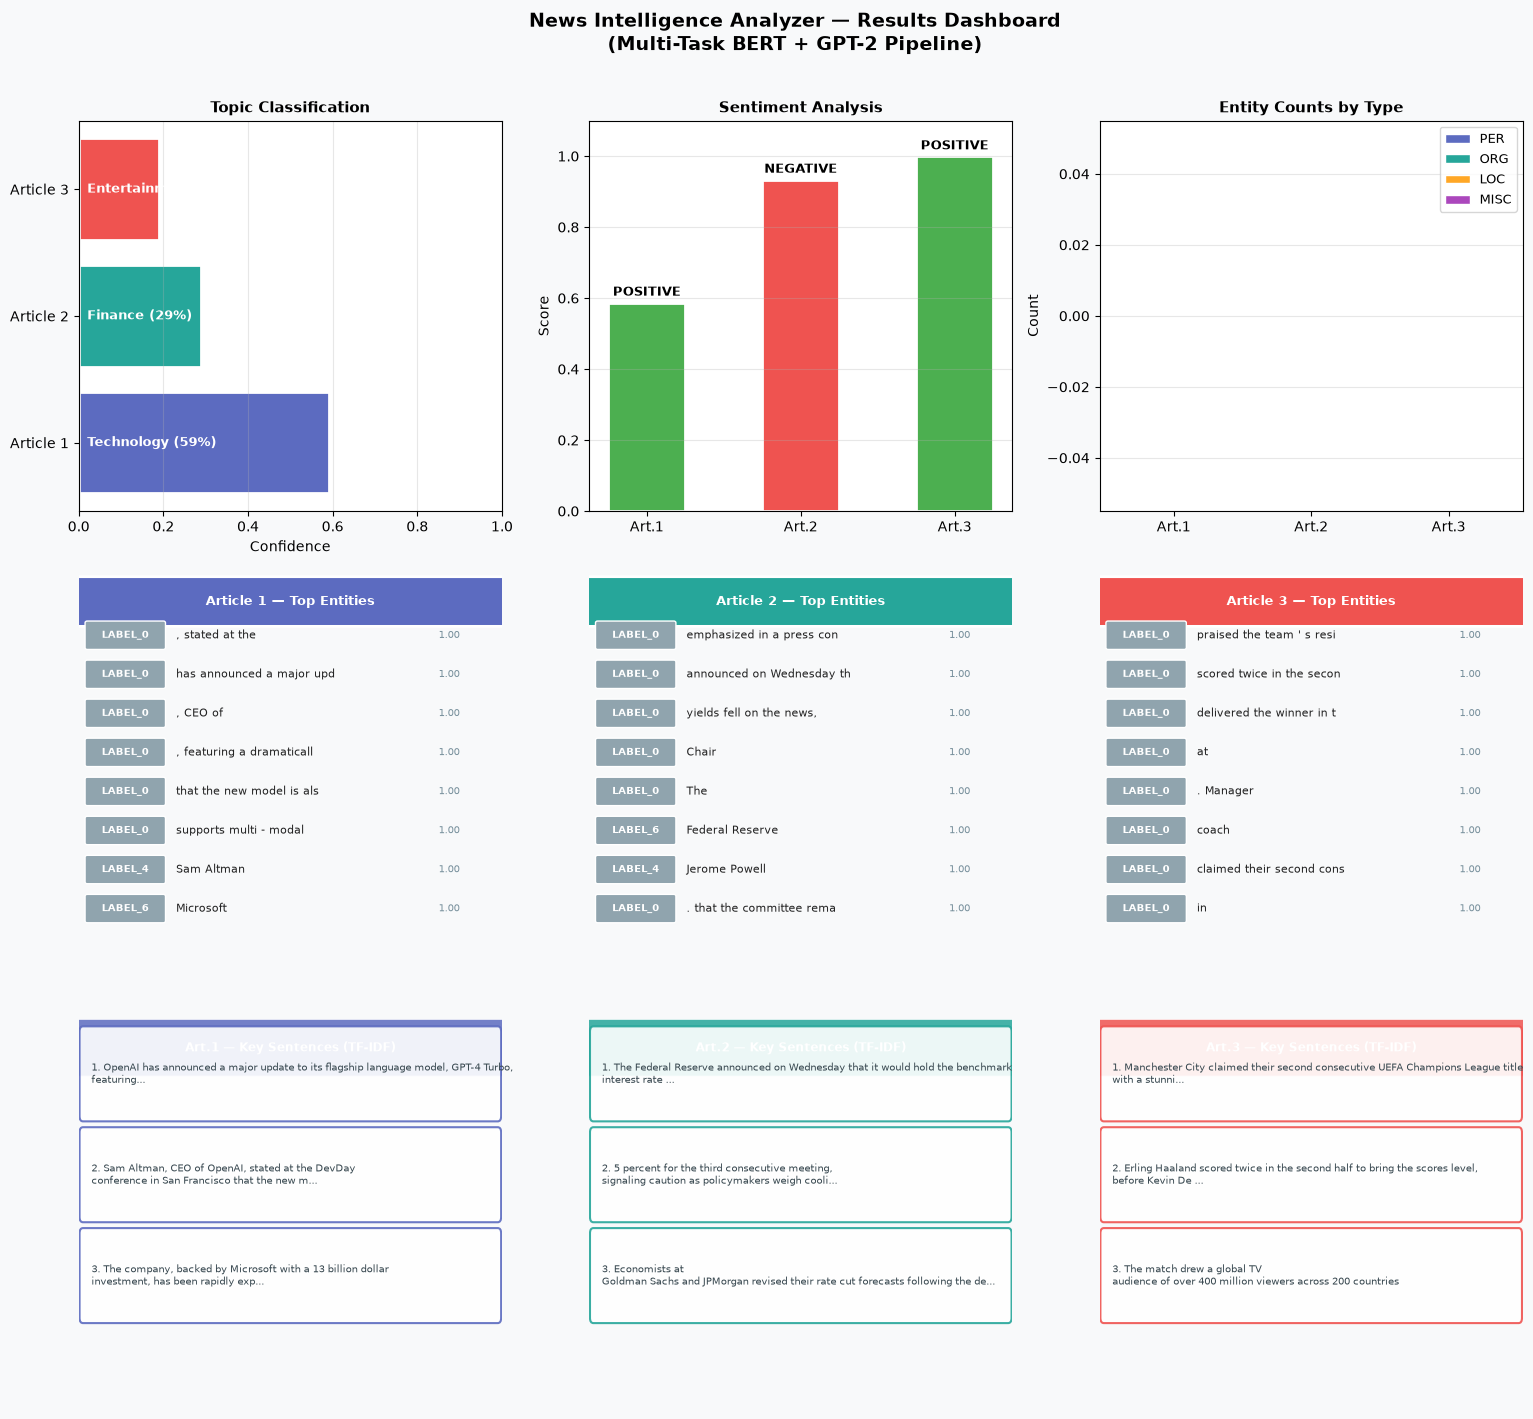

Dashboard saved to outputs/p8_capstone_dashboard.png


In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('#F8F9FA')

# Color palette per article
article_colors = ['#5C6BC0', '#26A69A', '#EF5350']
article_labels = [f'Article {r.article_id}' for r in results]

# ── Row 1: Topic & Sentiment ─────────────────────────────────────────────
ax1 = fig.add_subplot(3, 3, 1)
topics = [r.topic.title() for r in results]
confidences = [r.topic_confidence for r in results]
bars = ax1.barh(article_labels, confidences, color=article_colors, edgecolor='white', lw=2)
for bar, topic, conf in zip(bars, topics, confidences):
    ax1.text(0.02, bar.get_y() + bar.get_height()/2,
             f'{topic} ({conf:.0%})', va='center', fontsize=9, fontweight='bold', color='white')
ax1.set_xlim(0, 1.0)
ax1.set_title('Topic Classification', fontweight='bold', fontsize=11)
ax1.set_xlabel('Confidence')
ax1.grid(axis='x', alpha=0.3)

ax2 = fig.add_subplot(3, 3, 2)
sent_scores = [r.sentiment_score if r.sentiment == 'POSITIVE' else 1 - r.sentiment_score
               for r in results]
sent_colors = ['#4CAF50' if r.sentiment == 'POSITIVE' else '#EF5350' for r in results]
short_labels = [f'Art.{r.article_id}' for r in results]
bars2 = ax2.bar(short_labels, sent_scores, color=sent_colors, edgecolor='white', lw=2, width=0.5)
for bar, r in zip(bars2, results):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             r.sentiment, ha='center', fontsize=9, fontweight='bold')
ax2.set_ylim(0, 1.1)
ax2.set_title('Sentiment Analysis', fontweight='bold', fontsize=11)
ax2.set_ylabel('Score')
ax2.grid(axis='y', alpha=0.3)

# ── Row 1, Col 3: Entity counts ──────────────────────────────────────────
ax3 = fig.add_subplot(3, 3, 3)
entity_type_counts = {'PER': [], 'ORG': [], 'LOC': [], 'MISC': []}
for r in results:
    groups = {}
    for e in r.entities:
        groups[e.entity_type] = groups.get(e.entity_type, 0) + 1
    for etype in entity_type_counts:
        entity_type_counts[etype].append(groups.get(etype, 0))
x_pos = np.arange(len(results))
bar_width = 0.2
etype_colors = {'PER': '#5C6BC0', 'ORG': '#26A69A', 'LOC': '#FFA726', 'MISC': '#AB47BC'}
for i, (etype, counts) in enumerate(entity_type_counts.items()):
    ax3.bar(x_pos + i*bar_width, counts, width=bar_width,
            color=etype_colors[etype], label=etype, edgecolor='white', lw=1)
ax3.set_xticks(x_pos + bar_width * 1.5)
ax3.set_xticklabels([f'Art.{r.article_id}' for r in results])
ax3.set_title('Entity Counts by Type', fontweight='bold', fontsize=11)
ax3.set_ylabel('Count')
ax3.legend(fontsize=9)
ax3.grid(axis='y', alpha=0.3)

# ── Row 2: Entity detail panels ──────────────────────────────────────────
for col_idx, (r, color) in enumerate(zip(results, article_colors)):
    ax = fig.add_subplot(3, 3, 4 + col_idx)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 11)
    ax.axis('off')
    title_box = mpatches.FancyBboxPatch((0, 9.5), 10, 1.2,
                                         boxstyle='round,pad=0.1',
                                         facecolor=color, edgecolor='white', lw=2)
    ax.add_patch(title_box)
    ax.text(5, 10.1, f'Article {r.article_id} — Top Entities', ha='center',
            va='center', fontsize=9, fontweight='bold', color='white')
    # Show top 8 entities
    top_entities = r.entities[:8]
    etype_colors_short = {'PER': '#5C6BC0', 'ORG': '#26A69A', 'LOC': '#FFA726',
                          'MISC': '#AB47BC', 'DATE': '#78909C'}
    for j, e in enumerate(top_entities):
        y = 8.8 - j * 1.1
        ec = etype_colors_short.get(e.entity_type, '#90A4AE')
        tag_box = mpatches.FancyBboxPatch((0.2, y), 1.8, 0.7,
                                           boxstyle='round,pad=0.05',
                                           facecolor=ec, edgecolor='white', lw=1)
        ax.add_patch(tag_box)
        ax.text(1.1, y+0.35, e.entity_type, ha='center', va='center',
                fontsize=7, fontweight='bold', color='white')
        ax.text(2.3, y+0.35, f'{e.text[:25]}', va='center',
                fontsize=8, color='#212121')
        ax.text(9.0, y+0.35, f'{e.score:.2f}', va='center', ha='right',
                fontsize=7.5, color='#78909C')

# ── Row 3: Key sentences ─────────────────────────────────────────────────
for col_idx, (r, color) in enumerate(zip(results, article_colors)):
    ax = fig.add_subplot(3, 3, 7 + col_idx)
    ax.set_xlim(0, 10)
    ax.set_ylim(0, 6)
    ax.axis('off')
    title_box = mpatches.FancyBboxPatch((0, 5.2), 10, 0.7,
                                         boxstyle='round,pad=0.1',
                                         facecolor=color, alpha=0.85, edgecolor='white', lw=2)
    ax.add_patch(title_box)
    ax.text(5, 5.55, f'Art.{r.article_id} — Key Sentences (TF-IDF)', ha='center',
            va='center', fontsize=8.5, fontweight='bold', color='white')
    for j, sent in enumerate(r.key_sentences[:3]):
        y = 4.5 - j * 1.55
        rect = mpatches.FancyBboxPatch((0.1, y), 9.8, 1.3,
                                        boxstyle='round,pad=0.08',
                                        facecolor='#FFFFFF', edgecolor=color, lw=1.5, alpha=0.9)
        ax.add_patch(rect)
        ax.text(0.3, y+0.65,
                f'{j+1}. ' + (sent[:90] + '...' if len(sent) > 90 else sent),
                va='center', fontsize=7, color='#37474F', wrap=True)

plt.suptitle('News Intelligence Analyzer — Results Dashboard\n(Multi-Task BERT + GPT-2 Pipeline)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(r'outputs/p8_capstone_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Dashboard saved to outputs/p8_capstone_dashboard.png')

## 5. Performance Analysis — Model Profiling

Understanding inference latency is critical in production. Let's benchmark each module:

---

In [8]:
import time

test_text = TEST_ARTICLES[0]['text'].strip()
test_title = TEST_ARTICLES[0]['title']

modules = [
    ('Topic Classification (BART zero-shot)',
     lambda: topic_classifier(test_text[:500], candidate_labels=TOPIC_LABELS)),
    ('Named Entity Recognition (BERT-large)',
     lambda: ner_pipeline(test_text[:512])),
    ('Sentiment Analysis (DistilBERT)',
     lambda: sentiment_pipeline(test_text[:120])),
    ('Key Sentence Extraction (TF-IDF)',
     lambda: analyzer.extract_key_sentences(test_text)),
    ('GPT-2 Topic Expansion',
     lambda: generator_pipeline(
         f'Analysis of technology news: {test_title}. Key implications include',
         max_new_tokens=50, do_sample=False, pad_token_id=50256
     )),
]

print('Module Performance Benchmarks (3 runs, CPU)')
print('=' * 65)
print(f'{"Module":<44} {"Avg Time":>10} {"Model Type"}')
print('-' * 65)

timings = []
n_runs = 3
for name, fn in modules:
    run_times = []
    for _ in range(n_runs):
        t0 = time.time()
        fn()
        run_times.append(time.time() - t0)
    avg = sum(run_times) / n_runs
    timings.append((name, avg))
    model_type = 'Encoder (BERT)' if 'Extraction' not in name and 'GPT' not in name else (
        'TF-IDF' if 'TF-IDF' in name else 'Decoder (GPT)')
    print(f'{name:<44} {avg:>8.2f}s   {model_type}')

total = sum(t for _, t in timings)
print('-' * 65)
print(f'{"TOTAL PIPELINE":44} {total:>8.2f}s')
print(f'\nNote: GPU inference is typically 5-10x faster than CPU.')
print(f'Production tip: run modules in parallel using asyncio/ThreadPoolExecutor.')

Module Performance Benchmarks (3 runs, CPU)
Module                                         Avg Time Model Type
-----------------------------------------------------------------


Topic Classification (BART zero-shot)            0.37s   Encoder (BERT)


[transformers] Passing `generation_config` together with generation-related arguments=({'do_sample', 'pad_token_id', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Named Entity Recognition (BERT-large)            0.10s   Encoder (BERT)
Sentiment Analysis (DistilBERT)                  0.02s   Encoder (BERT)
Key Sentence Extraction (TF-IDF)                 0.00s   TF-IDF


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[transformers] Both `max_new_tokens` (=50) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


GPT-2 Topic Expansion                            2.28s   Decoder (GPT)
-----------------------------------------------------------------
TOTAL PIPELINE                                   2.78s

Note: GPU inference is typically 5-10x faster than CPU.
Production tip: run modules in parallel using asyncio/ThreadPoolExecutor.


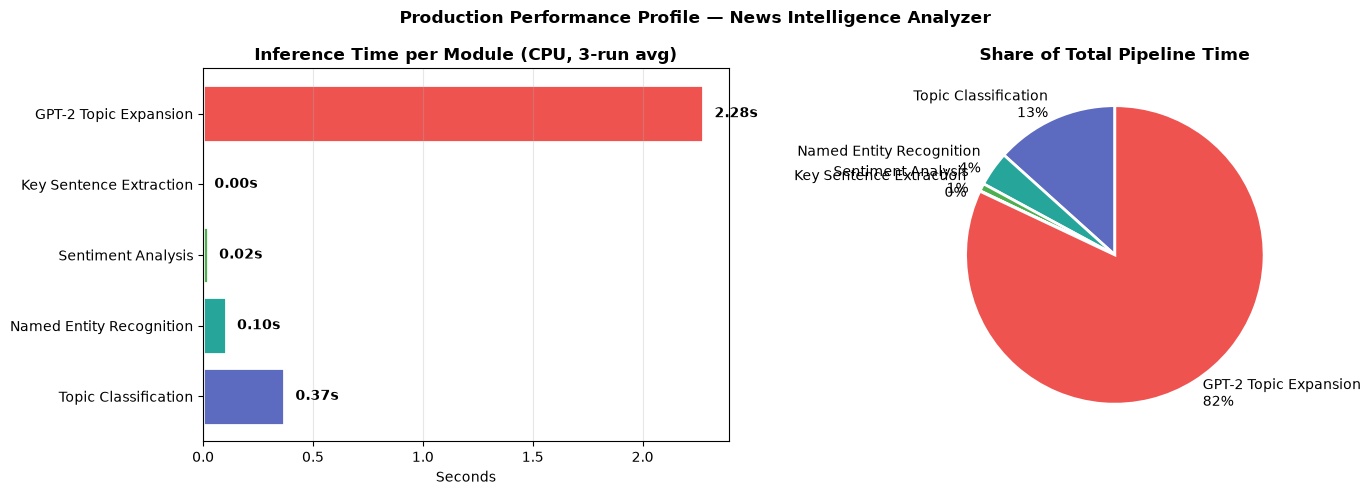

In [9]:
# Visualize latency profile
import matplotlib.pyplot as plt
import numpy as np

names = [t[0].split('(')[0].strip() for t in timings]
times = [t[1] for t in timings]
colors = ['#5C6BC0', '#26A69A', '#4CAF50', '#FFA726', '#EF5350']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
bars = axes[0].barh(names, times, color=colors, edgecolor='white', lw=2)
for bar, t in zip(bars, times):
    axes[0].text(bar.get_width() + 0.05, bar.get_y() + bar.get_height()/2,
                 f'{t:.2f}s', va='center', fontsize=10, fontweight='bold')
axes[0].set_title('Inference Time per Module (CPU, 3-run avg)', fontweight='bold')
axes[0].set_xlabel('Seconds')
axes[0].grid(axis='x', alpha=0.3)

# Pie chart: share of total time
pct_labels = [f'{n}\n{t/sum(times)*100:.0f}%' for n, t in zip(names, times)]
axes[1].pie(times, labels=pct_labels, colors=colors, startangle=90,
            wedgeprops=dict(edgecolor='white', lw=2), autopct='')
axes[1].set_title('Share of Total Pipeline Time', fontweight='bold')

plt.suptitle('Production Performance Profile — News Intelligence Analyzer', fontweight='bold')
plt.tight_layout()
plt.savefig(r'outputs/p8_capstone_profiling.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Production Extensions

The analyzer we built can be extended for real-world deployment in several ways:

### Parallel Processing with ThreadPoolExecutor
Each NLP module is independent — they can run simultaneously on different CPU cores:

```python
from concurrent.futures import ThreadPoolExecutor

def analyze_parallel(article):
    text = article['text']
    with ThreadPoolExecutor(max_workers=4) as executor:
        topic_future    = executor.submit(analyzer.classify_topic, text, TOPIC_LABELS)
        entity_future   = executor.submit(analyzer.extract_entities, text)
        sentiment_future= executor.submit(analyzer.analyze_sentiment, text)
        sentences_future= executor.submit(analyzer.extract_key_sentences, text)
    # Collect results after parallel execution
    return {
        'topic':     topic_future.result(),
        'entities':  entity_future.result(),
        'sentiment': sentiment_future.result(),
        'sentences': sentences_future.result(),
    }
```

### REST API with FastAPI
```python
from fastapi import FastAPI
app = FastAPI()

@app.post('/analyze')
async def analyze_article(article: dict):
    result = analyzer.analyze(article)  # analyzer pre-loaded at startup
    return result.__dict__
```

### Upgrading the Models
The modular design means you can swap any component without changing the rest:

| Current Model | Upgraded Alternative | Improvement |
|---|---|---|
| `bart-large-mnli` (zero-shot) | Fine-tuned BERT on your domain | 15–30% accuracy boost |
| `bert-large NER` | `dslim/bert-large-NER-uncased` | Better precision |
| `gpt2` (1.5B) | `gpt2-xl` or `meta-llama/Llama-3-8B` | Better generation quality |
| `TF-IDF` extractive | `facebook/bart-large-cnn` abstractive | Summary instead of extraction |

---

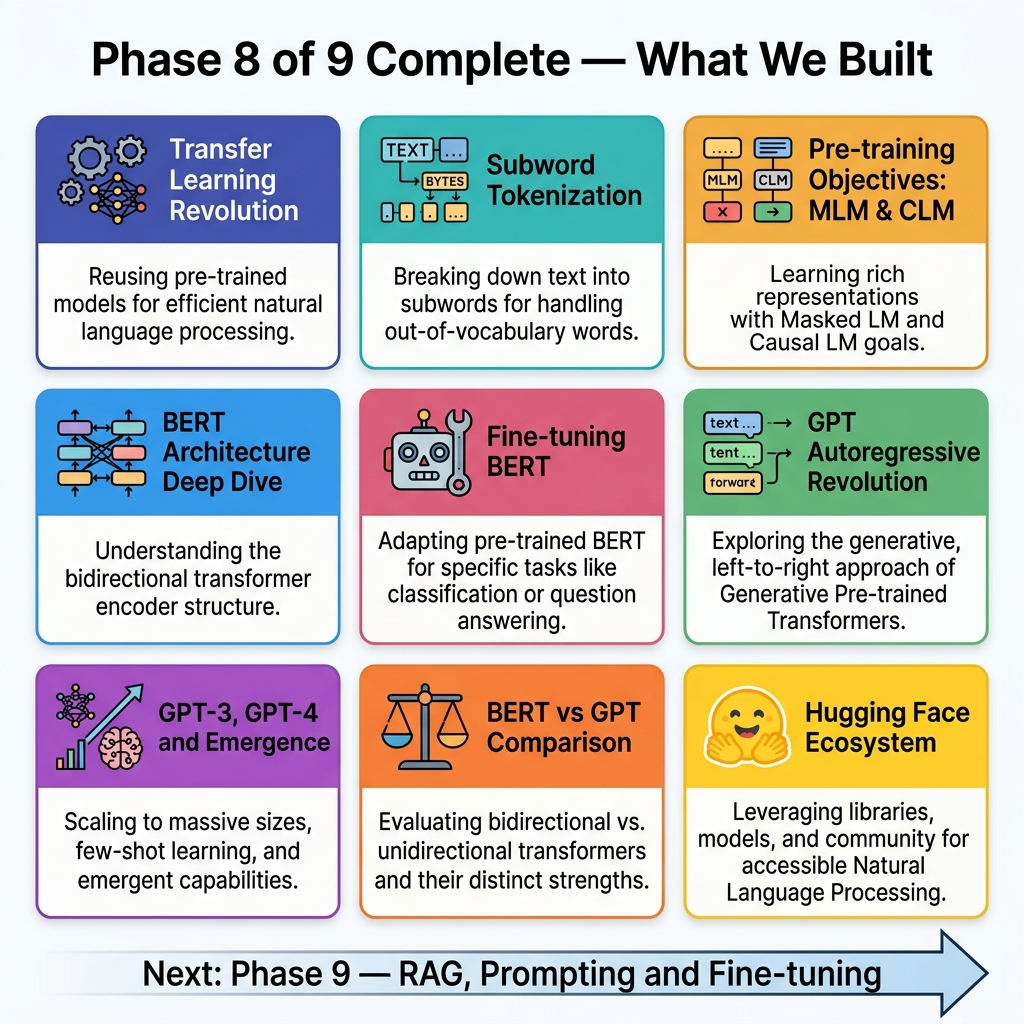

*Figure 2: Phase 8 Complete — All 9 notebooks covered, leading into Phase 9*



## 7. Phase 8 Retrospective — What We Mastered

Across all 10 notebooks, we traveled the complete arc from raw Transformers to deployed NLP applications:

| Notebook | Core Concept | Production Relevance |
|---|---|---|
| 1 | Transfer Learning | Foundation of all modern NLP |
| 2 | Subword Tokenization (BPE/WordPiece) | Every production tokenizer uses this |
| 3 | MLM vs CLM Pre-training | Determines whether to use BERT or GPT |
| 4 | BERT Architecture | Powers search, classification, NER at scale |
| 5 | Fine-tuning BERT | How to adapt pretrained models cheaply |
| 6 | GPT-1 & GPT-2 Architecture | Basis for all modern LLMs |
| 7 | GPT-3, RLHF, Emergent Abilities | How ChatGPT and production assistants work |
| 8 | BERT vs GPT Decision Guide | Choose the right architecture for any task |
| 9 | Hugging Face Ecosystem | One-line NLP for any task in production |
| **10** | **End-to-End Capstone** | **Multi-task pipeline combining both families** |

---

## 8. Bridge to Phase 9: RAG, Prompting & PEFT

Phase 9 builds directly on Phase 8's foundation:

| Phase 9 Topic | Builds On |
|---|---|
| **Prompt Engineering** | GPT's in-context learning (NB7) — now structured as a discipline |
| **RAG (Retrieval-Augmented Generation)** | BERT embeddings for retrieval + GPT for generation |
| **LoRA / PEFT** | Fine-tuning (NB5) — but for LLMs with <1% parameters updated |
| **LangChain / LlamaIndex** | Orchestration layers on top of the HF ecosystem (NB9) |
| **Evaluation** | Systematic benchmarking with ROUGE, BERTScore, human eval |

Phase 9 answers the question: *given a pre-trained LLM, how do you adapt it to your specific use case with minimal cost and maximum quality?*

---
*Phase 8, Notebook 10 of 10 — NLP From Scratch: Foundation to Advanced*

**Repository**: [github.com/naren-ghub/nlp-from-scratch](https://github.com/naren-ghub/nlp-from-scratch)

## 🎛️ Interactive Custom Article Analyzer

Use the interactive form below to analyze any custom article text of your choice, or call the user-defined function `analyze_custom_article(title, text)` directly from Python.

In [10]:
# ── Premium Styled Dynamic UI for Capstone News Intelligence Analyzer ──────
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

# 1. CSS Styling for modern, responsive card layout (dark theme)
CSS_STYLE = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Outfit:wght@300;400;600;700&display=swap');

.capstone-container {
    font-family: 'Outfit', -apple-system, BlinkMacSystemFont, 'Segoe UI', Roboto, sans-serif;
    background: linear-gradient(135deg, #181922 0%, #0d0e15 100%);
    border-radius: 16px;
    padding: 26px;
    color: #e0e2ee;
    box-shadow: 0 12px 36px rgba(0, 0, 0, 0.4);
    border: 1px solid rgba(255, 255, 255, 0.08);
    max-width: 860px;
    margin: 15px auto;
}

.capstone-header {
    background: linear-gradient(90deg, #b06ab3 0%, #4568dc 100%);
    -webkit-background-clip: text;
    -webkit-text-fill-color: transparent;
    font-size: 26px;
    font-weight: 700;
    margin-bottom: 6px;
    letter-spacing: -0.5px;
}

.capstone-subheader {
    font-size: 14px;
    color: #9295aa;
    margin-bottom: 22px;
}

/* Custom styled inputs override via widgets class names */
.widget-text input, .widget-textarea textarea {
    background-color: rgba(255, 255, 255, 0.04) !important;
    border: 1px solid rgba(255, 255, 255, 0.1) !important;
    border-radius: 8px !important;
    color: #ffffff !important;
    font-family: 'Outfit', sans-serif !important;
    padding: 10px 14px !important;
    transition: all 0.3s ease !important;
}

.widget-text input:focus, .widget-textarea textarea:focus {
    border-color: #5c6bc0 !important;
    box-shadow: 0 0 0 3px rgba(92, 107, 192, 0.25) !important;
    background-color: rgba(255, 255, 255, 0.06) !important;
}

/* Custom styled button */
.btn-analyze {
    background: linear-gradient(90deg, #5c6bc0 0%, #3f51b5 100%) !important;
    border: none !important;
    color: white !important;
    font-weight: 600 !important;
    font-size: 15px !important;
    border-radius: 8px !important;
    padding: 12px 24px !important;
    cursor: pointer !important;
    box-shadow: 0 4px 15px rgba(92, 107, 192, 0.35) !important;
    transition: all 0.3s cubic-bezier(0.25, 0.8, 0.25, 1) !important;
}

.btn-analyze:hover {
    transform: translateY(-2px) !important;
    box-shadow: 0 6px 20px rgba(92, 107, 192, 0.5) !important;
    filter: brightness(1.1) !important;
}

.btn-analyze:active {
    transform: translateY(1px) !important;
}

/* Structured Output Cards */
.output-card {
    background: rgba(255, 255, 255, 0.02);
    border-radius: 12px;
    border: 1px solid rgba(255, 255, 255, 0.05);
    padding: 22px;
    margin-top: 24px;
}

.result-title {
    font-size: 21px;
    font-weight: 600;
    color: #ffffff;
    border-bottom: 2px solid rgba(255, 255, 255, 0.06);
    padding-bottom: 12px;
    margin-bottom: 18px;
}

.metric-row {
    display: flex;
    gap: 15px;
    margin-bottom: 22px;
    flex-wrap: wrap;
}

.metric-badge {
    background: rgba(92, 107, 192, 0.12);
    border: 1px solid rgba(92, 107, 192, 0.3);
    color: #9fa8da;
    padding: 8px 16px;
    border-radius: 8px;
    font-size: 13.5px;
    font-weight: 600;
    display: inline-flex;
    align-items: center;
    gap: 8px;
}

.metric-badge.sentiment-positive {
    background: rgba(76, 175, 80, 0.12);
    border: 1px solid rgba(76, 175, 80, 0.3);
    color: #81c784;
}

.metric-badge.sentiment-negative {
    background: rgba(239, 83, 80, 0.12);
    border: 1px solid rgba(239, 83, 80, 0.3);
    color: #e57373;
}

.section-title {
    font-size: 13px;
    font-weight: 700;
    color: #9295aa;
    text-transform: uppercase;
    letter-spacing: 1px;
    margin-top: 18px;
    margin-bottom: 8px;
}

.entity-container {
    display: flex;
    flex-wrap: wrap;
    gap: 8px;
    margin-bottom: 12px;
}

.entity-pill {
    display: inline-flex;
    padding: 5px 11px;
    border-radius: 6px;
    font-size: 12.5px;
    font-weight: 600;
    border: 1px solid rgba(255, 255, 255, 0.08);
}

.entity-PER { background: rgba(92, 107, 192, 0.15); color: #9fa8da; border-color: rgba(92, 107, 192, 0.35); }
.entity-ORG { background: rgba(38, 166, 154, 0.15); color: #80cbc4; border-color: rgba(38, 166, 154, 0.35); }
.entity-LOC { background: rgba(255, 167, 38, 0.15); color: #ffcc80; border-color: rgba(255, 167, 38, 0.35); }
.entity-MISC { background: rgba(171, 71, 188, 0.15); color: #e1bee7; border-color: rgba(171, 71, 188, 0.35); }

.key-sentence {
    background: rgba(255, 255, 255, 0.02);
    border-left: 3px solid #5c6bc0;
    padding: 8px 12px;
    border-radius: 0 6px 6px 0;
    margin-bottom: 8px;
    font-size: 13.5px;
    line-height: 1.5;
}

.expansion-box {
    background: rgba(92, 107, 192, 0.04);
    border: 1px dashed rgba(92, 107, 192, 0.25);
    border-radius: 8px;
    padding: 12px 16px;
    font-size: 13.5px;
    line-height: 1.6;
    color: #c5cae9;
    font-style: italic;
}
</style>
"""

# 2. Render dynamic HTML formatted output from the pipeline result
def render_dashboard_html(r: AnalysisResult) -> str:
    # Topic Badge class
    topic_title = r.topic.title()
    
    # Sentiment styling
    sent_class = 'sentiment-positive' if r.sentiment == 'POSITIVE' else 'sentiment-negative'
    sent_symbol = '▲' if r.sentiment == 'POSITIVE' else '▼'
    
    # Entities pills
    entities_html = ''
    if r.entities:
        for ent in r.entities[:8]:
            etype = ent.entity_type
            entities_html += f'<span class="entity-pill entity-{etype}">{ent.text} <small style="opacity:0.7">{etype}</small></span>'
    else:
        entities_html = '<span style="color:#9295aa; font-style:italic;">No entities extracted.</span>'
        
    # Key sentences list
    sentences_html = ''
    for i, sent in enumerate(r.key_sentences, 1):
        sentences_html += f'<div class="key-sentence">{i}. {sent}</div>'
        
    # GPT-2 Expansion text
    expansion_text = r.generated_expansion.replace('\n', ' ').strip()
    if not expansion_text:
        expansion_text = "No commentary generated."
        
    html = f"""
    <div class="output-card">
        <div class="result-title">{r.title}</div>
        
        <div class="metric-row">
            <div class="metric-badge">
                🏷️ {topic_title} ({(r.topic_confidence * 100):.1f}% confidence)
            </div>
            <div class="metric-badge {sent_class}">
                {sent_symbol} {r.sentiment} ({(r.sentiment_score * 100):.1f}% positive metric)
            </div>
        </div>
        
        <div class="section-title">🔑 Named Entities Extracted (BERT)</div>
        <div class="entity-container">
            {entities_html}
        </div>
        
        <div class="section-title">📝 Key Sentences (TF-IDF Extractive)</div>
        <div>
            {sentences_html}
        </div>
        
        <div class="section-title">🤖 Expert AI Commentary (GPT-2 Generator)</div>
        <div class="expansion-box">
            "...{expansion_text}..."
        </div>
    </div>
    """
    return html

def analyze_custom_article_ui(title: str, text: str):
    """
    User-defined function to run the multi-task NLP pipelines and print results.
    """
    if not title.strip() or not text.strip():
        display(HTML('<div style="color:#ff8a80;">Please enter both a title and article text.</div>'))
        return
    
    custom_article = {
        'id': 99,
        'title': title,
        'text': text
    }
    
    display(HTML('<div style="color:#9295aa; font-style:italic;">Running multi-task model pipeline (BART, BERT, GPT-2)...</div>'))
    result = analyzer.analyze(custom_article)
    
    # Render the premium dashboard card directly in notebook outputs
    display(HTML(render_dashboard_html(result)))

def interactive_analysis_dashboard():
    """Creates and renders the full styled interactive UI in the output cell."""
    # Force CSS styling injection
    display(HTML(CSS_STYLE))
    
    # Input elements
    title_box = widgets.Text(
        value='SpaceX Falcon Heavy Successfully Launches New Satellite Constellation',
        placeholder='Enter article title here...',
        description='Title:',
        layout=widgets.Layout(width='85%')
    )
    title_box.add_class('widget-text')
    
    text_box = widgets.Textarea(
        value='SpaceX launched its Falcon Heavy rocket from Kennedy Space Center on Monday, sending a cluster of commercial communication satellites into orbit. The three first-stage boosters returned safely, landing on platforms in Florida. Observers in Orlando and Miami reported hearing thunderous sonic booms during reentry. Elon Musk praised the flight team on social media.',
        placeholder='Paste the full article body text here...',
        description='Body:',
        layout=widgets.Layout(width='85%', height='160px')
    )
    text_box.add_class('widget-textarea')
    
    btn = widgets.Button(
        description='Run Multi-Task NLP Analysis',
        layout=widgets.Layout(width='40%', height='45px')
    )
    btn.add_class('btn-analyze')
    
    out = widgets.Output()
    
    def trigger(b):
        with out:
            clear_output()
            analyze_custom_article_ui(title_box.value, text_box.value)
            
    btn.on_click(trigger)
    
    # Container div box
    form_layout = widgets.VBox([
        widgets.HTML('<div class="capstone-header">🧠 News Intelligence Analyzer Dashboard</div>'),
        widgets.HTML('<div class="capstone-subheader">Enter custom text to execute Zero-Shot Classification, Sentiment Analysis, NER, and Autoregressive GPT Commentary simultaneously.</div>'),
        title_box,
        widgets.HTML('<div style="height: 8px;"></div>'),
        text_box,
        widgets.HTML('<div style="height: 12px;"></div>'),
        btn,
        widgets.HTML('<div style="height: 12px;"></div>'),
        out
    ])
    form_layout.add_class('capstone-container')
    
    display(form_layout)

# Launch the dashboard
interactive_analysis_dashboard()